Loaded & filtered: (2268, 15)
consensus_label
active_single      1502
inactive_single     463
active              286
inactive             17
Name: count, dtype: int64

=== A) FP-only ===
[Fold 1] ROC-AUC=0.979 | PR-AUC=0.994 | BalAcc=0.905 | MCC=0.825 | n_test=227 | pos_test=184
[Fold 2] ROC-AUC=0.989 | PR-AUC=0.998 | BalAcc=0.966 | MCC=0.923 | n_test=227 | pos_test=188
[Fold 3] ROC-AUC=0.980 | PR-AUC=0.997 | BalAcc=0.873 | MCC=0.724 | n_test=227 | pos_test=199
[Fold 4] ROC-AUC=0.916 | PR-AUC=0.984 | BalAcc=0.779 | MCC=0.610 | n_test=227 | pos_test=195
[Fold 5] ROC-AUC=0.965 | PR-AUC=0.974 | BalAcc=0.930 | MCC=0.850 | n_test=227 | pos_test=192
[Fold 6] ROC-AUC=0.942 | PR-AUC=0.969 | BalAcc=0.871 | MCC=0.772 | n_test=227 | pos_test=149
[Fold 7] ROC-AUC=0.957 | PR-AUC=0.972 | BalAcc=0.828 | MCC=0.717 | n_test=227 | pos_test=140
[Fold 8] ROC-AUC=0.961 | PR-AUC=0.990 | BalAcc=0.898 | MCC=0.833 | n_test=227 | pos_test=190
[Fold 9] ROC-AUC=0.936 | PR-AUC=0.988 | BalAcc=0.850 | MCC=0.624 | n

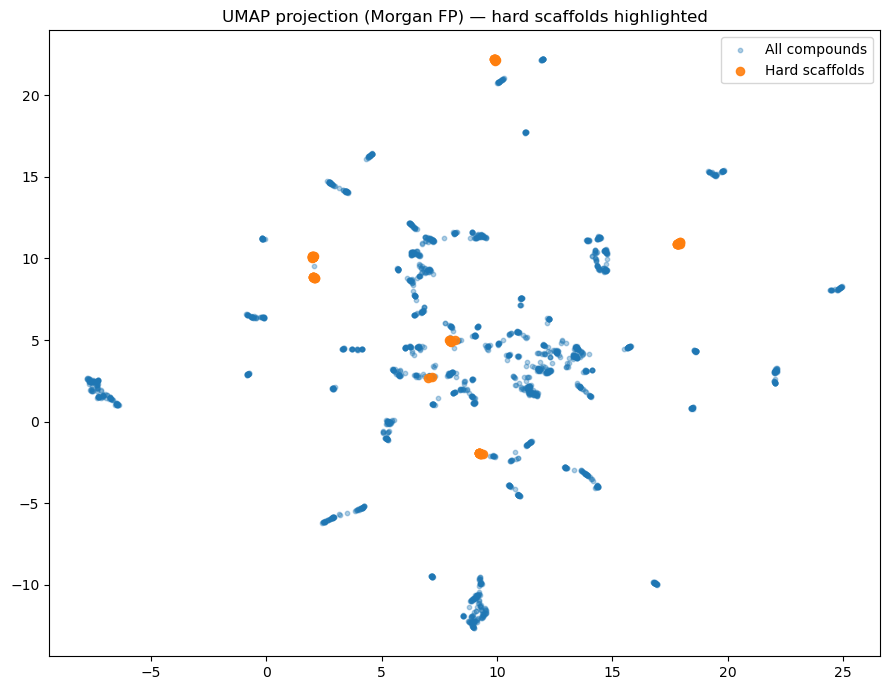

[SAVED] K:\M3_Project\M3_databases\umap_hard_scaffolds.png


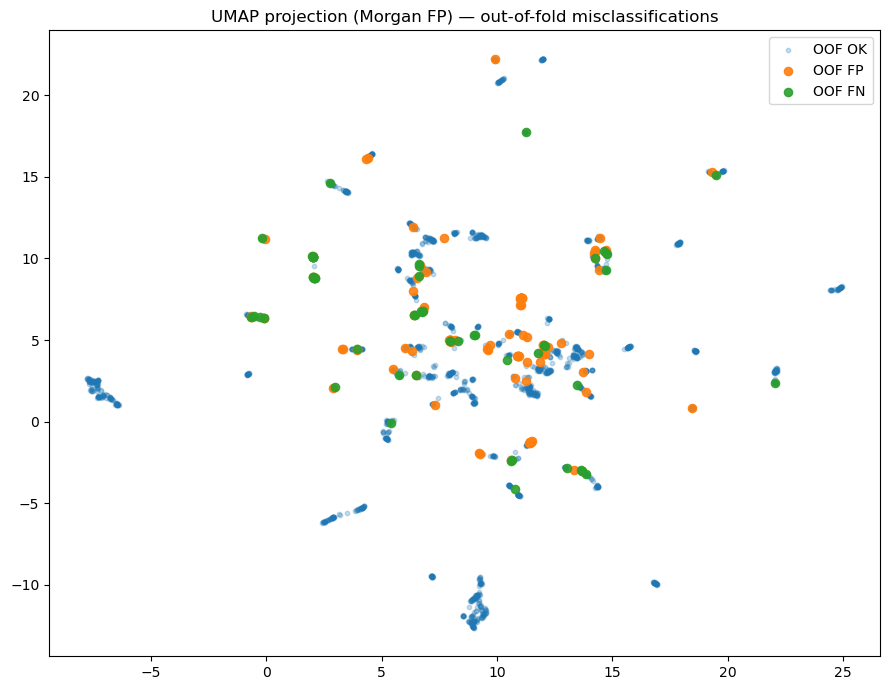

[SAVED] K:\M3_Project\M3_databases\umap_misclassifications.png

[DONE]
Outputs written to: K:\M3_Project\M3_databases


In [1]:
# =============================================================================
# FULL SCRIPT: M3 scaffold-CV ML + domain shift quantification + 2D projection
#   - NO OOP custom estimators (no BaseEstimator/TransformerMixin classes)
#   - Morgan FP (ECFP4-like): radius=2, 2048 bits, chirality optional
#   - Optional PhysChem (6 descriptors) concatenated to FP for training
#   - 10-fold scaffold CV (** GroupKFold **)
#   - Final model save (joblib) as a bundle (pipe + feature config)
#   - No-leakage OOF error analysis + per-scaffold performance + hard scaffolds
#   - Domain shift quantification for hard scaffolds:
#       * max Tanimoto similarity to training compounds (per compound)
#       * per-scaffold summary
#   - 2D chemical space projection using UMAP (Jaccard on bit-vectors)
#       * highlights hard scaffolds and misclassifications
#
# Requirements (openms_env):
#   - rdkit
#   - numpy, pandas
#   - scikit-learn
#   - joblib
#   - umap-learn   (pip install umap-learn)
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    balanced_accuracy_score,
)

from rdkit import Chem, DataStructs
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import Descriptors
from rdkit.DataStructs import ConvertToNumpyArray
from rdkit.Chem import rdFingerprintGenerator

import matplotlib.pyplot as plt
import cairosvg

try:
    import umap
except Exception as e:
    raise ImportError(
        "UMAP not available. Install with: pip install umap-learn"
    ) from e


# ----------------------------
# USER SETTINGS
# ----------------------------
DATA_PATH = r"K:\M3_Project\M3_databases\ChEMBL_M3_consensus_labels_more_negatives_with_meta.csv"

OUT_DIR = r"K:\M3_Project\M3_databases"
os.makedirs(OUT_DIR, exist_ok=True)

SAVE_MODEL_PATH        = os.path.join(OUT_DIR, "m3_fp_physchem_scaffoldcv.joblib")
MISCLASS_PATH          = os.path.join(OUT_DIR, "scaffold_cv_misclassifications.csv")
SCAF_SUM_PATH          = os.path.join(OUT_DIR, "scaffold_performance_summary.csv")
HARD_SCAF_PATH         = os.path.join(OUT_DIR, "hard_scaffolds.csv")

# new outputs for domain shift + projection
DOMAIN_SHIFT_PATH      = os.path.join(OUT_DIR, "hard_scaffolds_domain_shift_per_compound.csv")
DOMAIN_SHIFT_SUM_PATH  = os.path.join(OUT_DIR, "hard_scaffolds_domain_shift_summary.csv")
UMAP_PNG_PATH          = os.path.join(OUT_DIR, "umap_hard_scaffolds.png")
UMAP_MISCLASS_PNG_PATH = os.path.join(OUT_DIR, "umap_misclassifications.png")

# label mapping
POS_LABELS = {"active", "active_single"}
NEG_LABELS = {"inactive", "inactive_single"}

# sample weights (confidence weights)
WEIGHTS = {
    "active": 1.0,
    "inactive": 1.0,
    "active_single": 0.5,
    "inactive_single": 0.7,
}

# fingerprint settings
FP_RADIUS = 2
FP_NBITS = 2048
FP_USE_CHIRALITY = True
FP_USE_FEATURES = False   # feature invariants => FCFP-like

# scaffold CV
N_SPLITS = 10

# choose final model type
FINAL_USE_PHYSCHEM = True   # True => FP+physchem, False => FP-only

# hard scaffold threshold
HARD_MIN_N = 10
HARD_MCC_MAX = 0.5

# UMAP settings
UMAP_NEIGHBORS = 15
UMAP_MIN_DIST  = 0.10
UMAP_RANDOM_STATE = 42


def make_clf():
    return LogisticRegression(
        max_iter=5000,
        solver="liblinear",
        class_weight="balanced",
    )


# =============================================================================
# 1) LOAD + FILTER DATA
# =============================================================================
df = pd.read_csv(DATA_PATH)

required = {"molecule_chembl_id", "smiles", "consensus_label"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in input CSV: {missing}")

df = df[df["consensus_label"].isin(POS_LABELS | NEG_LABELS)].copy()
df = df.dropna(subset=["smiles"]).copy()
df["smiles"] = df["smiles"].astype(str).str.strip()
df = df[df["smiles"] != ""].copy()

df["y"] = df["consensus_label"].isin(POS_LABELS).astype(int)
df["w"] = df["consensus_label"].map(WEIGHTS).astype(float)

print("Loaded & filtered:", df.shape)
print(df["consensus_label"].value_counts())


# =============================================================================
# 2) SCAFFOLDS (GROUPS)
# =============================================================================
def smiles_to_scaffold(smi: str) -> str:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return ""
    scaf = MurckoScaffold.GetScaffoldForMol(mol)
    if scaf is None:
        return ""
    return Chem.MolToSmiles(scaf, isomericSmiles=False)

df["scaffold"] = df["smiles"].apply(smiles_to_scaffold)
bad = df["scaffold"].eq("")
if bad.any():
    print(f"Dropping {bad.sum()} rows with invalid SMILES/scaffold.")
    df = df[~bad].copy()

X_smiles = df["smiles"].values
y = df["y"].values.astype(int)
w = df["w"].values.astype(float)
groups = df["scaffold"].values

cv = GroupKFold(n_splits=N_SPLITS)


# =============================================================================
# 3) FEATURE FUNCTIONS (NO OOP)
# =============================================================================
def _make_morgan_generator():
    atom_inv_gen = None
    if FP_USE_FEATURES:
        atom_inv_gen = rdFingerprintGenerator.GetMorganFeatureAtomInvGen()

    gen = rdFingerprintGenerator.GetMorganGenerator(
        radius=FP_RADIUS,
        fpSize=FP_NBITS,
        includeChirality=FP_USE_CHIRALITY,
        atomInvariantsGenerator=atom_inv_gen,
    )
    return gen


def morgan_fp_matrix(smiles_list):
    """
    Return dense FP matrix (n_samples, FP_NBITS) float32.
    Generator is created inside (no pickle issues).
    """
    smiles_list = np.asarray(smiles_list, dtype=object)
    gen = _make_morgan_generator()

    X = np.zeros((len(smiles_list), FP_NBITS), dtype=np.float32)
    tmp = np.zeros((FP_NBITS,), dtype=np.int8)

    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            continue
        bv = gen.GetFingerprint(mol)
        tmp[:] = 0
        ConvertToNumpyArray(bv, tmp)
        X[i, :] = tmp

    return X


def physchem_matrix(smiles_list):
    """
    Compact physchem set (6 features):
      MolWt, MolLogP, HBD, HBA, TPSA, NumRotatableBonds
    """
    smiles_list = np.asarray(smiles_list, dtype=object)
    X = np.zeros((len(smiles_list), 6), dtype=np.float32)

    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            X[i, :] = np.nan
            continue
        X[i, 0] = Descriptors.MolWt(mol)
        X[i, 1] = Descriptors.MolLogP(mol)
        X[i, 2] = Descriptors.NumHDonors(mol)
        X[i, 3] = Descriptors.NumHAcceptors(mol)
        X[i, 4] = Descriptors.TPSA(mol)
        X[i, 5] = Descriptors.NumRotatableBonds(mol)

    if np.isnan(X).any():
        med = np.nanmedian(X, axis=0)
        r, c = np.where(np.isnan(X))
        X[r, c] = med[c]

    return X


def build_X(smiles_list, use_physchem: bool):
    X_fp = morgan_fp_matrix(smiles_list)
    if not use_physchem:
        return X_fp
    X_pc = physchem_matrix(smiles_list)
    return np.hstack([X_fp, X_pc]).astype(np.float32)


def make_pipe():
    return Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", make_clf()),
    ])


# =============================================================================
# 4) SCAFFOLD-CV EVALUATION (FP-only vs FP+physchem)
# =============================================================================
def eval_mode(name: str, use_physchem: bool):
    metrics = {"roc_auc": [], "pr_auc": [], "bal_acc": [], "mcc": []}
    print(f"\n=== {name} ===")

    for fold, (train_idx, test_idx) in enumerate(
        cv.split(X_smiles, y, groups=groups),
        start=1
    ):
        X_train = build_X(X_smiles[train_idx], use_physchem=use_physchem)
        X_test  = build_X(X_smiles[test_idx],  use_physchem=use_physchem)

        y_train, y_test = y[train_idx], y[test_idx]
        w_train = w[train_idx]

        fold_pipe = make_pipe()
        fold_pipe.fit(X_train, y_train, clf__sample_weight=w_train)

        proba = fold_pipe.predict_proba(X_test)[:, 1]
        pred = (proba >= 0.5).astype(int)

        roc = roc_auc_score(y_test, proba)
        pr  = average_precision_score(y_test, proba)
        bal = balanced_accuracy_score(y_test, pred)
        mcc = matthews_corrcoef(y_test, pred)

        metrics["roc_auc"].append(roc)
        metrics["pr_auc"].append(pr)
        metrics["bal_acc"].append(bal)
        metrics["mcc"].append(mcc)

        print(
            f"[Fold {fold}] ROC-AUC={roc:.3f} | PR-AUC={pr:.3f} | "
            f"BalAcc={bal:.3f} | MCC={mcc:.3f} | n_test={len(test_idx)} | pos_test={int(y_test.sum())}"
        )

    print(f"\n--- {name} summary ---")
    for k, vals in metrics.items():
        vals = np.asarray(vals, dtype=float)
        print(f"{k}: mean={vals.mean():.3f}  std={vals.std():.3f}")

    return metrics


m1 = eval_mode("A) FP-only", use_physchem=False)
m2 = eval_mode("B) FP + physchem", use_physchem=True)


# =============================================================================
# 5) FIT FINAL MODEL ON ALL DATA + SAVE (PICKLABLE)
# =============================================================================
final_use_physchem = bool(FINAL_USE_PHYSCHEM)

X_all = build_X(X_smiles, use_physchem=final_use_physchem)
final_pipe = make_pipe()
final_pipe.fit(X_all, y, clf__sample_weight=w)

model_bundle = {
    "pipe": final_pipe,
    "use_physchem": final_use_physchem,
    "fp_radius": FP_RADIUS,
    "fp_nbits": FP_NBITS,
    "fp_use_chirality": FP_USE_CHIRALITY,
    "fp_use_features": FP_USE_FEATURES,
    "physchem_dim": 6,
    "threshold": 0.5,
}
joblib.dump(model_bundle, SAVE_MODEL_PATH)
print("\n[SAVED MODEL]", SAVE_MODEL_PATH)


# =============================================================================
# 6) NO-LEAKAGE OOF ERROR ANALYSIS + PER-SCAFFOLD PERFORMANCE + HARD SCAFFOLDS
# =============================================================================
rows = []
for fold, (train_idx, test_idx) in enumerate(
    cv.split(X_smiles, y, groups=groups),
    start=1
):
    X_train = build_X(X_smiles[train_idx], use_physchem=final_use_physchem)
    X_test  = build_X(X_smiles[test_idx],  use_physchem=final_use_physchem)

    y_train, y_test = y[train_idx], y[test_idx]
    w_train = w[train_idx]

    fold_pipe = make_pipe()
    fold_pipe.fit(X_train, y_train, clf__sample_weight=w_train)

    proba = fold_pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= model_bundle["threshold"]).astype(int)

    for i, idx in enumerate(test_idx):
        true_i = int(y_test[i])
        pred_i = int(pred[i])

        err = "OK"
        if pred_i == 1 and true_i == 0:
            err = "FP"
        elif pred_i == 0 and true_i == 1:
            err = "FN"

        rows.append({
            "fold": fold,
            "row_index": int(idx),
            "molecule_chembl_id": df.iloc[idx]["molecule_chembl_id"],
            "consensus_label": df.iloc[idx]["consensus_label"],
            "smiles": df.iloc[idx]["smiles"],
            "scaffold": df.iloc[idx]["scaffold"],
            "true_label": true_i,
            "pred_label": pred_i,
            "p_active": float(proba[i]),
            "error_type": err,
        })

err_df = pd.DataFrame(rows)
err_df.to_csv(MISCLASS_PATH, index=False)
print("\n[SAVED]", MISCLASS_PATH)
print(err_df["error_type"].value_counts())


# per-scaffold performance
scaf_stats = []
for scaf, g in err_df.groupby("scaffold"):
    y_true = g["true_label"].values
    y_pred = g["pred_label"].values

    # MCC undefined if only one class present within that scaffold's held-out set
    if len(np.unique(y_true)) < 2:
        continue

    scaf_stats.append({
        "scaffold": scaf,
        "n": int(len(g)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "bal_acc": float(balanced_accuracy_score(y_true, y_pred)),
        "n_errors": int((g["error_type"] != "OK").sum()),
        "pos_frac": float(np.mean(y_true)),
    })

scaf_df = pd.DataFrame(scaf_stats).sort_values(["mcc", "n"], ascending=[True, False])
scaf_df.to_csv(SCAF_SUM_PATH, index=False)
print("[SAVED]", SCAF_SUM_PATH)
print(scaf_df.head(10))

hard_scaffolds = scaf_df.query(f"n >= {HARD_MIN_N} and mcc < {HARD_MCC_MAX}").copy()
hard_scaffolds.to_csv(HARD_SCAF_PATH, index=False)
print("\n[SAVED]", HARD_SCAF_PATH)
print(f"Hard scaffolds (n>={HARD_MIN_N} & MCC<{HARD_MCC_MAX}):", len(hard_scaffolds))
print(hard_scaffolds.head(10))


# =============================================================================
# 7) DOMAIN SHIFT QUANTIFICATION FOR HARD SCAFFOLDS
#    For each compound in a hard scaffold:
#      - compute max Tanimoto similarity to ANY compound outside that scaffold
# =============================================================================
def compute_fp_objects(smiles_list):
    smiles_list = np.asarray(smiles_list, dtype=object)
    gen = _make_morgan_generator()
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            fps.append(None)
        else:
            fps.append(gen.GetFingerprint(mol))
    return fps

all_smiles = df["smiles"].values
all_fps = compute_fp_objects(all_smiles)

hard_scaf_set = set(hard_scaffolds["scaffold"].tolist())
domain_rows = []

if len(hard_scaf_set) == 0:
    print("\n[DOMAIN SHIFT] No hard scaffolds found under current criteria -> skipping.")
else:
    # For efficiency, precompute indices with valid fps
    valid_idx = np.array([i for i, fp in enumerate(all_fps) if fp is not None], dtype=int)

    for scaf in hard_scaf_set:
        mask_scaf = (df["scaffold"].values == scaf)
        scaf_idx = valid_idx[mask_scaf[valid_idx]]
        train_idx = valid_idx[~mask_scaf[valid_idx]]  # "training space" = outside this scaffold

        train_fps = [all_fps[i] for i in train_idx]   # list of ExplicitBitVect

        for idx in scaf_idx:
            fp = all_fps[idx]
            sims = DataStructs.BulkTanimotoSimilarity(fp, train_fps)
            domain_rows.append({
                "scaffold": scaf,
                "row_index": int(idx),
                "molecule_chembl_id": df.iloc[idx]["molecule_chembl_id"],
                "consensus_label": df.iloc[idx]["consensus_label"],
                "true_label": int(df.iloc[idx]["y"]),
                "max_sim_to_outside_scaffold": float(np.max(sims)) if len(sims) else np.nan,
                "mean_sim_to_outside_scaffold": float(np.mean(sims)) if len(sims) else np.nan,
                "p95_sim_to_outside_scaffold": float(np.percentile(sims, 95)) if len(sims) else np.nan,
            })

    domain_df = pd.DataFrame(domain_rows)
    domain_df.to_csv(DOMAIN_SHIFT_PATH, index=False)
    print("\n[SAVED]", DOMAIN_SHIFT_PATH)

    # scaffold-level summary
    domain_sum = (
        domain_df
        .groupby("scaffold")
        .agg(
            n=("row_index", "count"),
            maxSim_mean=("max_sim_to_outside_scaffold", "mean"),
            maxSim_min=("max_sim_to_outside_scaffold", "min"),
            p95Sim_mean=("p95_sim_to_outside_scaffold", "mean"),
            meanSim_mean=("mean_sim_to_outside_scaffold", "mean"),
        )
        .reset_index()
        .sort_values(["maxSim_mean"], ascending=True)
    )
    domain_sum.to_csv(DOMAIN_SHIFT_SUM_PATH, index=False)
    print("[SAVED]", DOMAIN_SHIFT_SUM_PATH)
    print(domain_sum)


# =============================================================================
# 8) 2D PROJECTION (UMAP) + PLOTS
#    Use FP-only bit vectors; UMAP metric='jaccard' is appropriate for binary.
# =============================================================================
print("\n[UMAP] Computing 2D embedding ...")

X_fp_only = morgan_fp_matrix(df["smiles"].values).astype(np.float32)

reducer = umap.UMAP(
    n_neighbors=UMAP_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric="jaccard",
    random_state=UMAP_RANDOM_STATE,
)

embedding = reducer.fit_transform(X_fp_only)
df["umap1"] = embedding[:, 0]
df["umap2"] = embedding[:, 1]


# ---- Plot 1: highlight hard scaffolds
plt.figure(figsize=(9, 7))
plt.scatter(df["umap1"], df["umap2"], s=10, alpha=0.35, label="All compounds")

if len(hard_scaf_set) > 0:
    mask_hard = df["scaffold"].isin(hard_scaf_set)
    plt.scatter(df.loc[mask_hard, "umap1"], df.loc[mask_hard, "umap2"], s=35, alpha=0.9, label="Hard scaffolds")

plt.title("UMAP projection (Morgan FP) — hard scaffolds highlighted")
plt.legend()
plt.tight_layout()
plt.savefig(UMAP_PNG_PATH, dpi=200)
plt.show()
print("[SAVED]", UMAP_PNG_PATH)


# ---- Plot 2: highlight misclassifications (FP/FN)
# Merge OOF error labels back to df by row_index
err_map = err_df.set_index("row_index")["error_type"]
df["error_type_oof"] = df.index.to_series().map(err_map).fillna("NA")

plt.figure(figsize=(9, 7))

# background: OK predictions
mask_ok = df["error_type_oof"].eq("OK")
plt.scatter(df.loc[mask_ok, "umap1"], df.loc[mask_ok, "umap2"], s=10, alpha=0.25, label="OOF OK")

# FP
mask_fp = df["error_type_oof"].eq("FP")
plt.scatter(df.loc[mask_fp, "umap1"], df.loc[mask_fp, "umap2"], s=35, alpha=0.9, label="OOF FP")

# FN
mask_fn = df["error_type_oof"].eq("FN")
plt.scatter(df.loc[mask_fn, "umap1"], df.loc[mask_fn, "umap2"], s=35, alpha=0.9, label="OOF FN")

plt.title("UMAP projection (Morgan FP) — out-of-fold misclassifications")
plt.legend()
plt.tight_layout()
plt.savefig(UMAP_MISCLASS_PNG_PATH, dpi=200)
plt.show()
print("[SAVED]", UMAP_MISCLASS_PNG_PATH)


# =============================================================================
# 9) OPTIONAL: HELPER FOR INFERENCE (LOAD + PREDICT)
# =============================================================================
def load_model_and_predict(smiles_list, model_path=SAVE_MODEL_PATH):
    bundle = joblib.load(model_path)
    pipe = bundle["pipe"]
    use_physchem = bundle["use_physchem"]
    threshold = bundle.get("threshold", 0.5)

    X = build_X(np.asarray(smiles_list, dtype=object), use_physchem=use_physchem)
    proba = pipe.predict_proba(X)[:, 1]
    pred = (proba >= threshold).astype(int)
    return proba, pred


print("\n[DONE]")
print("Outputs written to:", OUT_DIR)

[LOAD] K:\M3_Project\M3_databases\scaffold_cv_misclassifications.csv
[SHAPE] (2268, 10)
[COLUMNS] ['fold', 'row_index', 'molecule_chembl_id', 'consensus_label', 'smiles', 'scaffold', 'true_label', 'pred_label', 'p_active', 'error_type']

=== 1) OOF Calibration + Brier ===
[PREVALENCE] 0.7884
[BASELINE BRIER] 0.166849  (prevalence-only)

[ERROR] No OOF probabilities found in the CSV.
        Needed one of columns: oof_prob/proba/y_prob/p_hat/pred_proba/prob/probability
        Calibration curve + Brier require probabilities.

=== 2) Decision-boundary probability distributions ===
[SKIP] No probabilities available -> cannot plot probability distributions.

=== 3) Per-scaffold calibration (Brier by scaffold) ===
[SKIP] Need both probabilities and 'scaffold' column.

=== 4) Calibration on hard scaffolds vs rest (optional) ===
[SKIP] Need both probabilities and 'scaffold' column.

[DONE]


[LOAD] K:\M3_Project\M3_databases\scaffold_cv_misclassifications.csv
[SHAPE] (2268, 10)
[COLUMNS] ['fold', 'row_index', 'molecule_chembl_id', 'consensus_label', 'smiles', 'scaffold', 'true_label', 'pred_label', 'p_active', 'error_type']

=== 1) OOF Calibration + Brier ===
[PREVALENCE] 0.7884
[BASELINE BRIER] 0.166849  (prevalence-only)
[BRIER] 0.058806
[BRIER IMPROVEMENT vs baseline] +0.108042


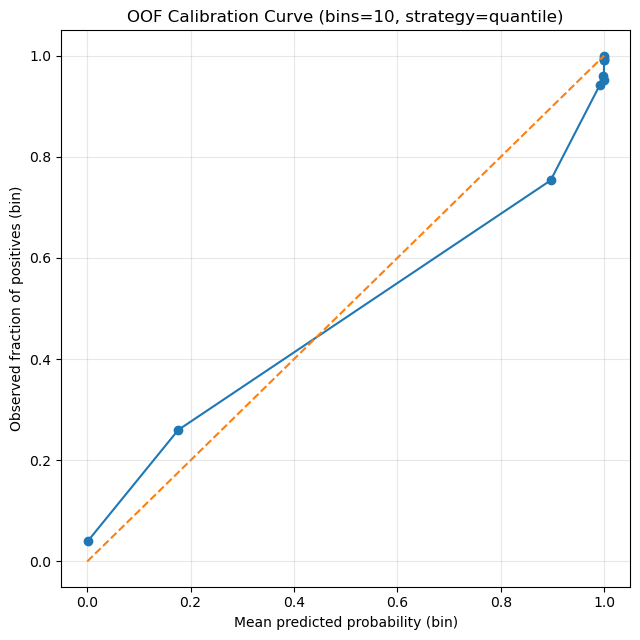


=== 2) Decision-boundary probability distributions ===


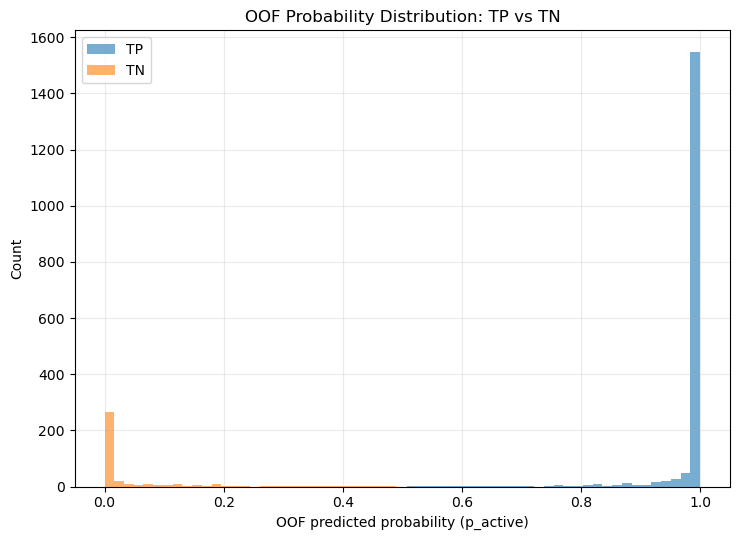

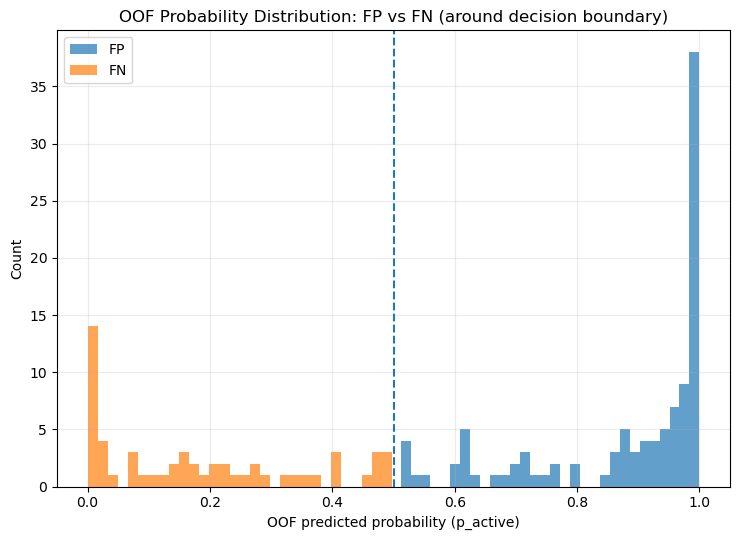

[COUNTS] TP=1732 | TN=374 | FP=106 | FN=56

=== 3) Per-scaffold Brier (calibration stability by scaffold) ===
[SCAFFOLDS ANALYZED] 82 (n>=5)
[Brier median] 0.000300 | [Brier mean] 0.071314

[TOP 20 WORST SCAFFOLDS by Brier]


,scaffold,n,pos_frac,brier
51,O=C(c1ccc(-c2ccccc2)cc1)N1CCN(C(=O)c2ccc3cc[nH...,15,0.000000,0.979930
80,c1coc(C2CCCN2)c1,12,0.000000,0.576652
79,c1ccccc1,12,0.250000,0.494388
50,O=C(OCCc1ccccc1)C1=C(c2ccccc2)CCNC1,6,0.500000,0.448688
26,O=C(Nc1ccc(N2CCNCC2)cc1)c1ccccc1,6,0.000000,0.438248
77,c1ccc2c(c1)CCN1Cc3c(ccc4[nH]ccc34)OC21,18,0.611111,0.371501
24,O=C(NCc1cccc(-c2cccc(CN3CCNCC3)c2)c1)c1ccc2c(c...,10,0.900000,0.370489
3,C1=C(c2ccccc2)CCNC1,7,0.857143,0.287404
20,O=C(NC1CCNCC1)C(c1ccccc1)C1CCCC1,6,1.000000,0.263346
57,O=C1Nc2ccccc2N(C(=O)CN2CCCCC2)c2ccccc21,7,0.285714,0.247538


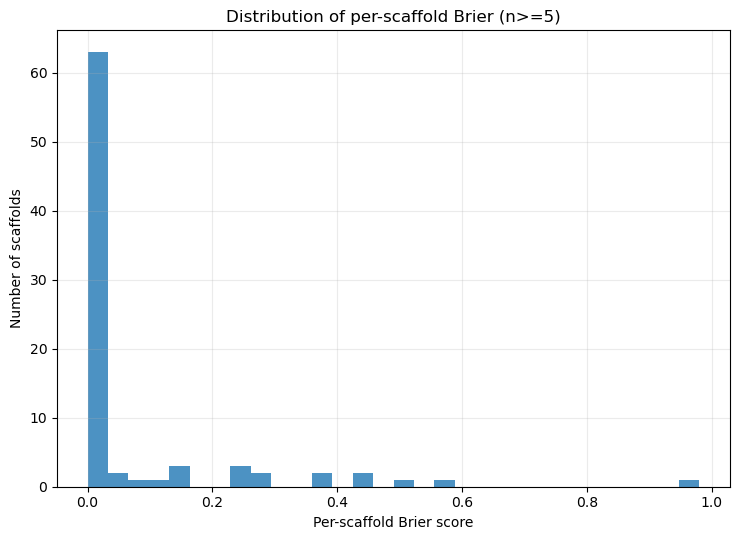


[DONE]


In [9]:
# =============================================================================
# OOF Calibration + Brier + Per-scaffold Brier + Decision-boundary plots
# Works with your file columns:
#   - true_label (0/1)
#   - pred_label (0/1)
#   - p_active (OOF probability for active)
#   - scaffold
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# ------------------------------ CONFIG ---------------------------------------
PATH = r"K:\M3_Project\M3_databases\scaffold_cv_misclassifications.csv"

N_BINS = 10
CAL_STRATEGY = "quantile"     # "uniform" also ok
MIN_SCAFFOLD_N = 5
TOPK_WORST_SCAFFOLDS = 20

# ------------------------------ LOAD -----------------------------------------
if not os.path.exists(PATH):
    raise FileNotFoundError(f"File not found:\n{PATH}")

df = pd.read_csv(PATH)
print("[LOAD]", PATH)
print("[SHAPE]", df.shape)
print("[COLUMNS]", list(df.columns))

# ------------------------------ NORMALIZE COLS -------------------------------
# Labels
if "true_label" in df.columns:
    df["binary_label"] = pd.to_numeric(df["true_label"], errors="coerce").fillna(0).astype(int)
elif "binary_label" in df.columns:
    df["binary_label"] = pd.to_numeric(df["binary_label"], errors="coerce").fillna(0).astype(int)
elif "consensus_label" in df.columns:
    df["binary_label"] = df["consensus_label"].isin(["active", "active_single"]).astype(int)
else:
    raise KeyError("Need 'true_label' or 'binary_label' or 'consensus_label' to build y_true.")

# Probabilities
# Your file uses p_active as the OOF probability for the positive class
if "p_active" in df.columns:
    df["oof_prob"] = pd.to_numeric(df["p_active"], errors="coerce")
elif "oof_prob" in df.columns:
    df["oof_prob"] = pd.to_numeric(df["oof_prob"], errors="coerce")
else:
    raise KeyError("Need probability column: 'p_active' (preferred) or 'oof_prob'.")

# Predicted labels (optional but useful)
if "pred_label" in df.columns:
    df["y_pred"] = pd.to_numeric(df["pred_label"], errors="coerce").fillna(0).astype(int)
else:
    df["y_pred"] = (df["oof_prob"] >= 0.5).astype(int)

# Clean missing probs
n_missing = int(df["oof_prob"].isna().sum())
if n_missing:
    print(f"[WARN] oof_prob has {n_missing} missing values -> dropping those rows for calibration.")
    df = df.dropna(subset=["oof_prob"]).copy()

df["oof_prob"] = df["oof_prob"].clip(0.0, 1.0).astype(float)

scaffold_ok = "scaffold" in df.columns
if not scaffold_ok:
    print("[WARN] 'scaffold' column missing -> per-scaffold analysis will be skipped.")

# ------------------------------ 1) CALIBRATION + BRIER -----------------------
print("\n=== 1) OOF Calibration + Brier ===")
y_true = df["binary_label"].values
y_prob = df["oof_prob"].values

prevalence = float(y_true.mean())
baseline_brier = prevalence * (1.0 - prevalence)
brier = float(brier_score_loss(y_true, y_prob))

print(f"[PREVALENCE] {prevalence:.4f}")
print(f"[BASELINE BRIER] {baseline_brier:.6f}  (prevalence-only)")
print(f"[BRIER] {brier:.6f}")
print(f"[BRIER IMPROVEMENT vs baseline] {baseline_brier - brier:+.6f}")

prob_true, prob_pred = calibration_curve(
    y_true,
    y_prob,
    n_bins=N_BINS,
    strategy=CAL_STRATEGY
)

plt.figure(figsize=(6.5, 6.5))
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("Mean predicted probability (bin)")
plt.ylabel("Observed fraction of positives (bin)")
plt.title(f"OOF Calibration Curve (bins={N_BINS}, strategy={CAL_STRATEGY})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------ 2) DECISION-BOUNDARY PLOTS -------------------
print("\n=== 2) Decision-boundary probability distributions ===")
y_pred = df["y_pred"].values

TP = (y_true == 1) & (y_pred == 1)
TN = (y_true == 0) & (y_pred == 0)
FP = (y_true == 0) & (y_pred == 1)
FN = (y_true == 1) & (y_pred == 0)

plt.figure(figsize=(7.5, 5.5))
plt.hist(y_prob[TP], bins=30, alpha=0.6, label="TP")
plt.hist(y_prob[TN], bins=30, alpha=0.6, label="TN")
plt.xlabel("OOF predicted probability (p_active)")
plt.ylabel("Count")
plt.title("OOF Probability Distribution: TP vs TN")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7.5, 5.5))
if FP.sum() > 0:
    plt.hist(y_prob[FP], bins=30, alpha=0.7, label="FP")
if FN.sum() > 0:
    plt.hist(y_prob[FN], bins=30, alpha=0.7, label="FN")
plt.axvline(0.5, linestyle="--")
plt.xlabel("OOF predicted probability (p_active)")
plt.ylabel("Count")
plt.title("OOF Probability Distribution: FP vs FN (around decision boundary)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"[COUNTS] TP={TP.sum()} | TN={TN.sum()} | FP={FP.sum()} | FN={FN.sum()}")

# ------------------------------ 3) PER-SCAFFOLD BRIER ------------------------
print("\n=== 3) Per-scaffold Brier (calibration stability by scaffold) ===")
if not scaffold_ok:
    print("[SKIP] No scaffold column.")
else:
    rows = []
    for scaf, g in df.groupby("scaffold"):
        n = len(g)
        if n < MIN_SCAFFOLD_N:
            continue
        yt = g["binary_label"].values
        yp = g["oof_prob"].values
        bs = float(brier_score_loss(yt, yp))
        rows.append((scaf, n, float(np.mean(yt)), bs))

    scaf_brier = pd.DataFrame(rows, columns=["scaffold", "n", "pos_frac", "brier"])
    scaf_brier.sort_values(["brier", "n"], ascending=[False, False], inplace=True)

    print(f"[SCAFFOLDS ANALYZED] {len(scaf_brier)} (n>={MIN_SCAFFOLD_N})")
    print(f"[Brier median] {scaf_brier['brier'].median():.6f} | [Brier mean] {scaf_brier['brier'].mean():.6f}")

    print(f"\n[TOP {TOPK_WORST_SCAFFOLDS} WORST SCAFFOLDS by Brier]")
    display(scaf_brier.head(TOPK_WORST_SCAFFOLDS))

    plt.figure(figsize=(7.5, 5.5))
    plt.hist(scaf_brier["brier"].values, bins=30, alpha=0.8)
    plt.xlabel("Per-scaffold Brier score")
    plt.ylabel("Number of scaffolds")
    plt.title(f"Distribution of per-scaffold Brier (n>={MIN_SCAFFOLD_N})")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

print("\n[DONE]")